# 02 — Signal Processing & Feature Extraction

Raw time-domain signals are hard for ML models to learn from directly. This notebook
applies classical signal processing techniques to expose the echo structure that
encodes blockage information.

**Techniques covered:**
1. **STFT Spectrogram** — time-frequency representation (2-D image for CNN)
2. **Signal Envelope** — Hilbert-transform-based amplitude trace
3. **Peak Detection** — classical DSP baseline for echo localisation
4. **Sliding-window feature extraction** — compact per-window statistics
5. **Batch spectrogram generation** — saving features for ML training

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

from src.simulation import AcousticPipeSimulator, PipeConfig, Blockage
from src.features   import (
    compute_spectrogram, spectrogram_batch,
    extract_envelope_features, detect_echo_peaks,
    normalise_signals,
)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Load dataset
signals   = np.load('../data/signals.npy')
labels    = np.load('../data/labels.npy')
positions = np.load('../data/positions.npy')

FS = 44_100
print(f'Loaded: signals={signals.shape}  labels={labels.shape}')

Loaded: signals=(2000, 15434)  labels=(2000,)


## 2.1 STFT Spectrogram

The **Short-Time Fourier Transform (STFT)** slides a window across the signal and
computes the spectrum at each position. The result is a 2-D time-frequency image:
- **X-axis**: time
- **Y-axis**: frequency
- **Colour**: energy (dB scale)

Echoes appear as **vertical energy bands** at the blockage echo time — the same
frequency profile as the original pulse, shifted in time.

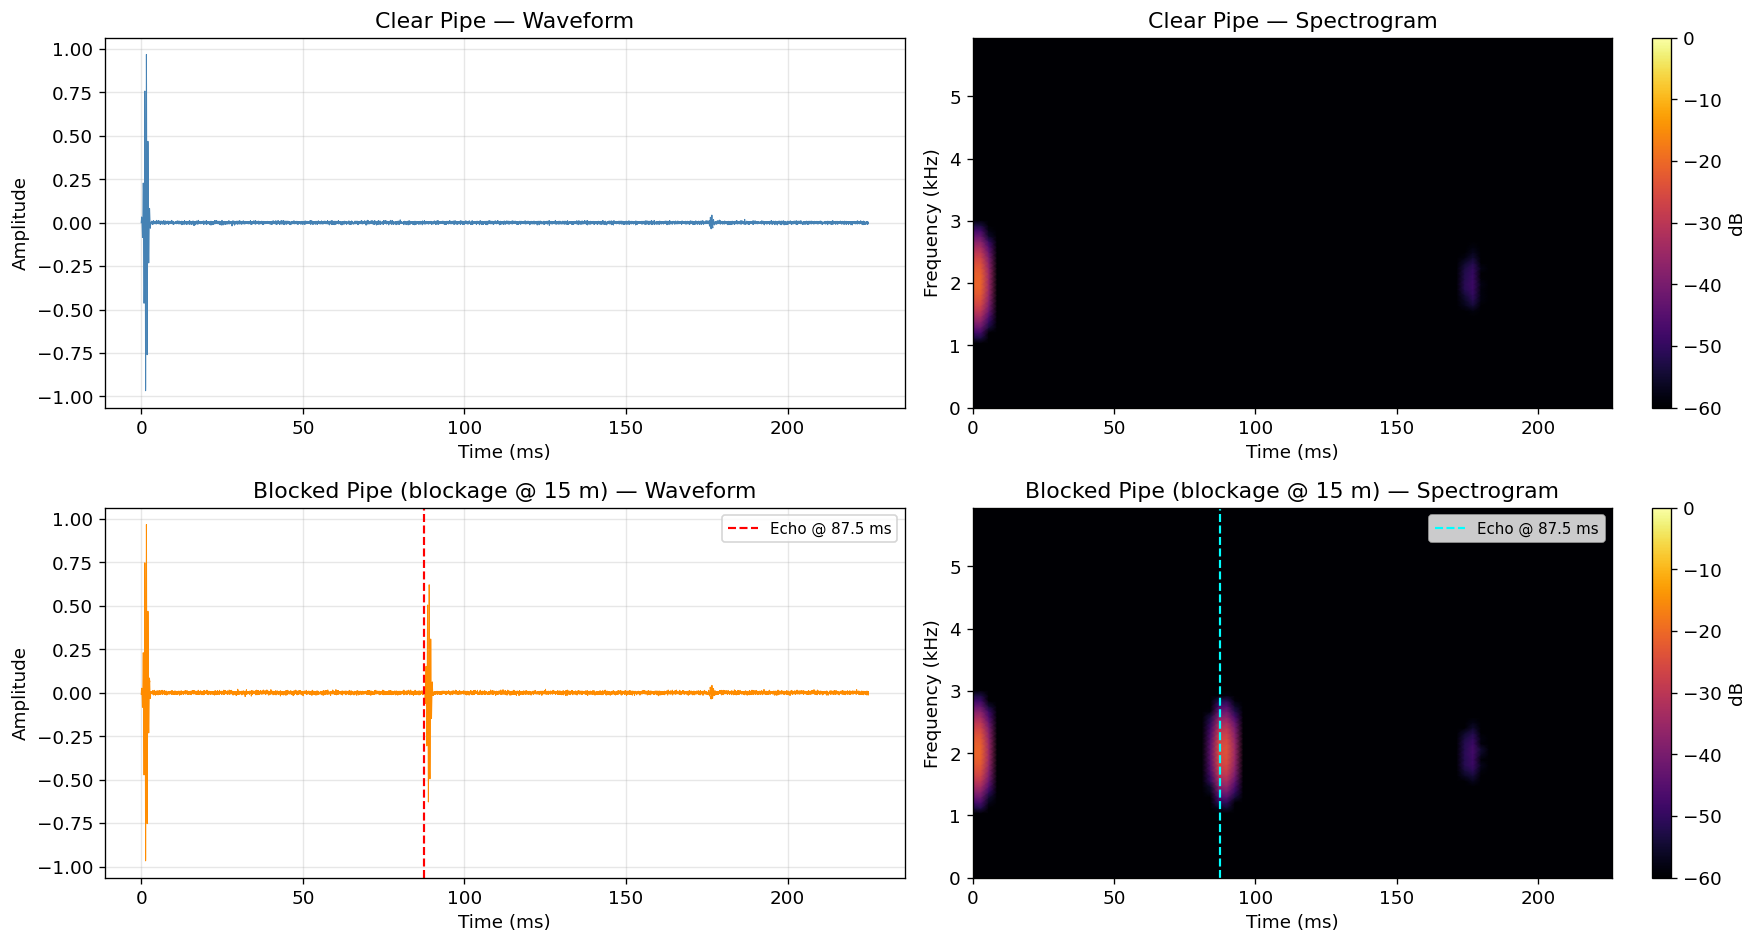

In [2]:
sim = AcousticPipeSimulator(fs=FS)
pipe = PipeConfig(length=30.0, speed_of_sound=343.0, attenuation_db_m=0.08)

t_clear, sig_clear, _              = sim.simulate(pipe, [], snr_db=20)
t_blk,   sig_blk,   echo_times_blk = sim.simulate(pipe, [Blockage(15.0, 0.75)], snr_db=20)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

for row, (t, sig, title, echo_t) in enumerate([
    (t_clear, sig_clear, 'Clear Pipe',   []),
    (t_blk,   sig_blk,   'Blocked Pipe (blockage @ 15 m)', echo_times_blk),
]):
    # Time domain
    axes[row, 0].plot(t * 1000, sig, linewidth=0.6, color='steelblue' if row==0 else 'darkorange')
    for et in echo_t:
        axes[row, 0].axvline(et * 1000, color='red', linestyle='--', linewidth=1.3,
                              label=f'Echo @ {et*1000:.1f} ms')
    if echo_t: axes[row, 0].legend(fontsize=9)
    axes[row, 0].set(xlabel='Time (ms)', ylabel='Amplitude', title=f'{title} — Waveform')
    axes[row, 0].grid(alpha=0.3)

    # Spectrogram
    f, t_spec, Sdb = compute_spectrogram(sig, fs=FS, freq_max=6000)
    im = axes[row, 1].pcolormesh(t_spec * 1000, f / 1000, Sdb,
                                  shading='gouraud', cmap='inferno', vmin=-60, vmax=0)
    for et in echo_t:
        axes[row, 1].axvline(et * 1000, color='cyan', linestyle='--', linewidth=1.3,
                              label=f'Echo @ {et*1000:.1f} ms')
    if echo_t: axes[row, 1].legend(fontsize=9)
    axes[row, 1].set(xlabel='Time (ms)', ylabel='Frequency (kHz)', title=f'{title} — Spectrogram')
    plt.colorbar(im, ax=axes[row, 1], label='dB')

plt.tight_layout()
plt.savefig('../outputs/plots/02_spectrograms.png', bbox_inches='tight')
plt.show()

## 2.2 Signal Envelope (Hilbert Transform)

The **analytic signal envelope** (via Hilbert transform) gives the instantaneous
amplitude of the signal. Echo peaks appear as clear bumps in the envelope,
making them easy to detect with simple peak-finding algorithms.

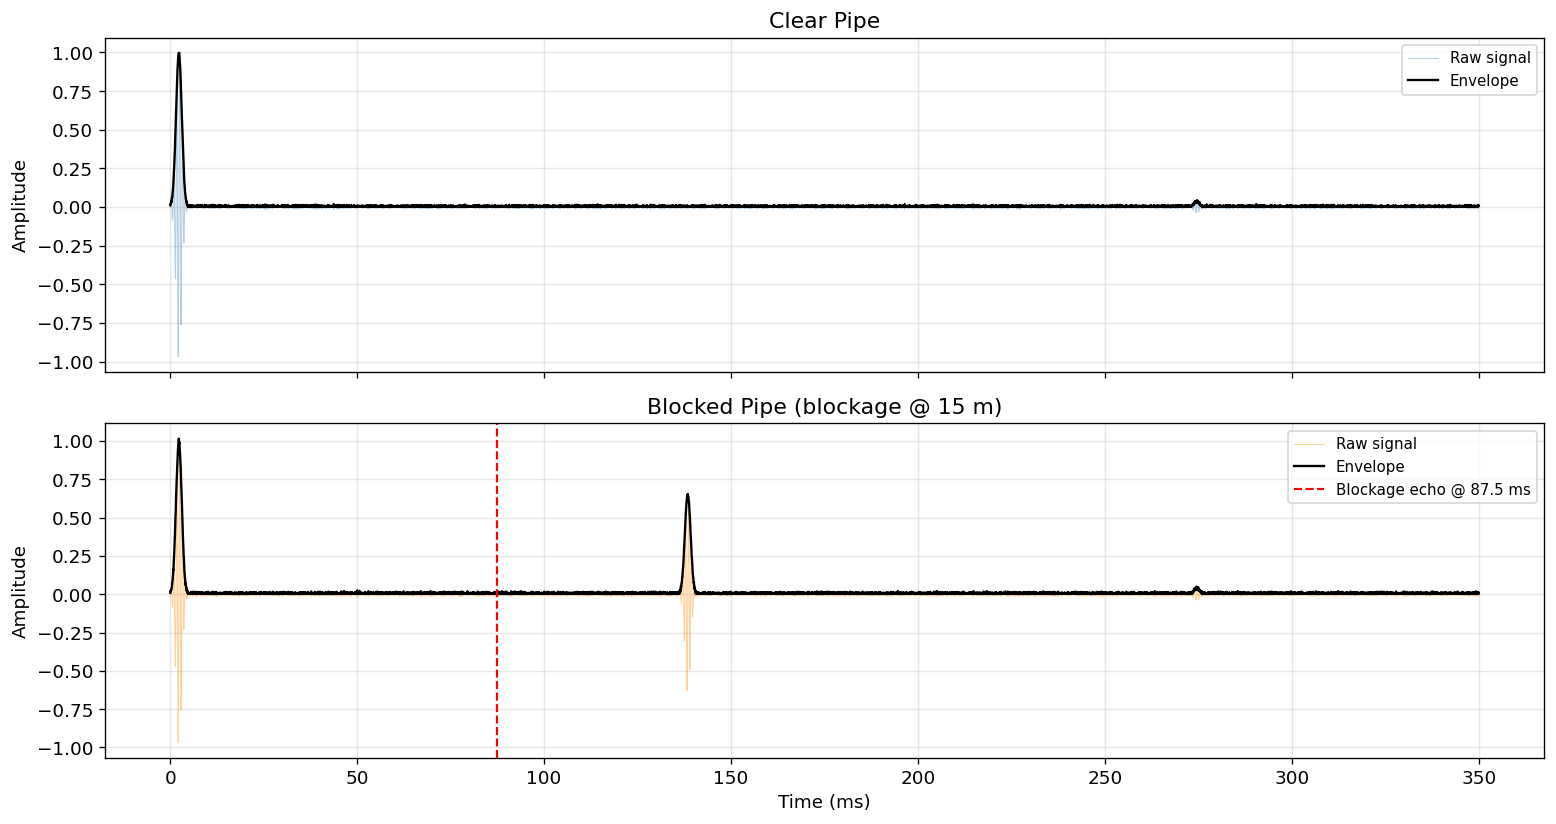

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

for ax, sig, title, color, echo_t in [
    (axes[0], sig_clear, 'Clear Pipe', 'steelblue',  []),
    (axes[1], sig_blk,   'Blocked Pipe (blockage @ 15 m)', 'darkorange', echo_times_blk),
]:
    envelope = np.abs(hilbert(sig))
    t_ms = np.linspace(0, 0.35, len(sig)) * 1000
    ax.plot(t_ms, sig,      alpha=0.4, linewidth=0.6, color=color, label='Raw signal')
    ax.plot(t_ms, envelope, linewidth=1.4, color='black',  label='Envelope')
    for et in echo_t:
        ax.axvline(et * 1000, color='red', linestyle='--', linewidth=1.3,
                   label=f'Blockage echo @ {et*1000:.1f} ms')
    ax.set(ylabel='Amplitude', title=title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time (ms)')
plt.tight_layout()
plt.savefig('../outputs/plots/02_envelope.png', bbox_inches='tight')
plt.show()

## 2.3 Classical DSP Baseline: Peak Detection

Before applying ML, we test a **classical DSP approach**: compute the envelope,
ignore the initial pulse, and find peaks. This is interpretable and fast — but
struggles at low SNR and with multiple overlapping echoes.

Ground-truth echo times (ms): ['46.6', '128.3']
Detected echo times    (ms): ['46.8', '128.4', '175.6']

  Detected echo @ 46.8 ms → estimated position = 8.0 m
  Detected echo @ 128.4 ms → estimated position = 22.0 m
  Detected echo @ 175.6 ms → estimated position = 30.1 m


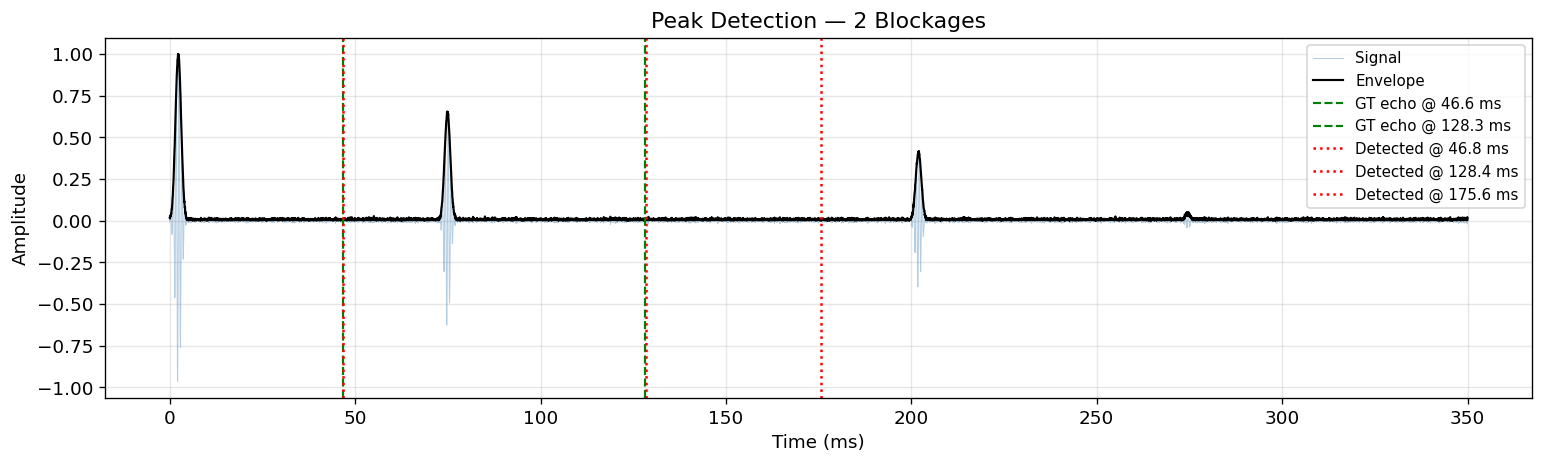

In [4]:
from src.features import detect_echo_peaks
from src.simulation import echo_time_to_position

# Test on a signal with 2 blockages
blks_2 = [Blockage(8.0, 0.7), Blockage(22.0, 0.5)]
_, sig_2blk, gt_echoes = sim.simulate(pipe, blks_2, snr_db=20)

peak_times, peak_ampls = detect_echo_peaks(sig_2blk, fs=FS, min_prominence=0.03)

print('Ground-truth echo times (ms):', [f'{e*1000:.1f}' for e in gt_echoes])
print('Detected echo times    (ms):', [f'{p*1000:.1f}' for p in peak_times])
print()
for pt in peak_times:
    est_pos = echo_time_to_position(pt)
    print(f'  Detected echo @ {pt*1000:.1f} ms → estimated position = {est_pos:.1f} m')

t_ms = np.linspace(0, 0.35, len(sig_2blk)) * 1000
envelope = np.abs(hilbert(sig_2blk))

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(t_ms, sig_2blk, alpha=0.4, linewidth=0.6, color='steelblue', label='Signal')
ax.plot(t_ms, envelope, linewidth=1.3, color='black', label='Envelope')
for et in gt_echoes:
    ax.axvline(et*1000, color='green', linestyle='--', linewidth=1.3, label=f'GT echo @ {et*1000:.1f} ms')
for pt in peak_times:
    ax.axvline(pt*1000, color='red', linestyle=':', linewidth=1.5, label=f'Detected @ {pt*1000:.1f} ms')
ax.set(xlabel='Time (ms)', ylabel='Amplitude', title='Peak Detection — 2 Blockages')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/02_peak_detection.png', bbox_inches='tight')
plt.show()

## 2.4 Sliding-Window Feature Extraction
For each 5 ms window, we compute [RMS, peak amplitude, zero-crossing rate,
spectral centroid]. This gives a compact time-series of features that clearly
shows anomalous energy at echo arrival times.

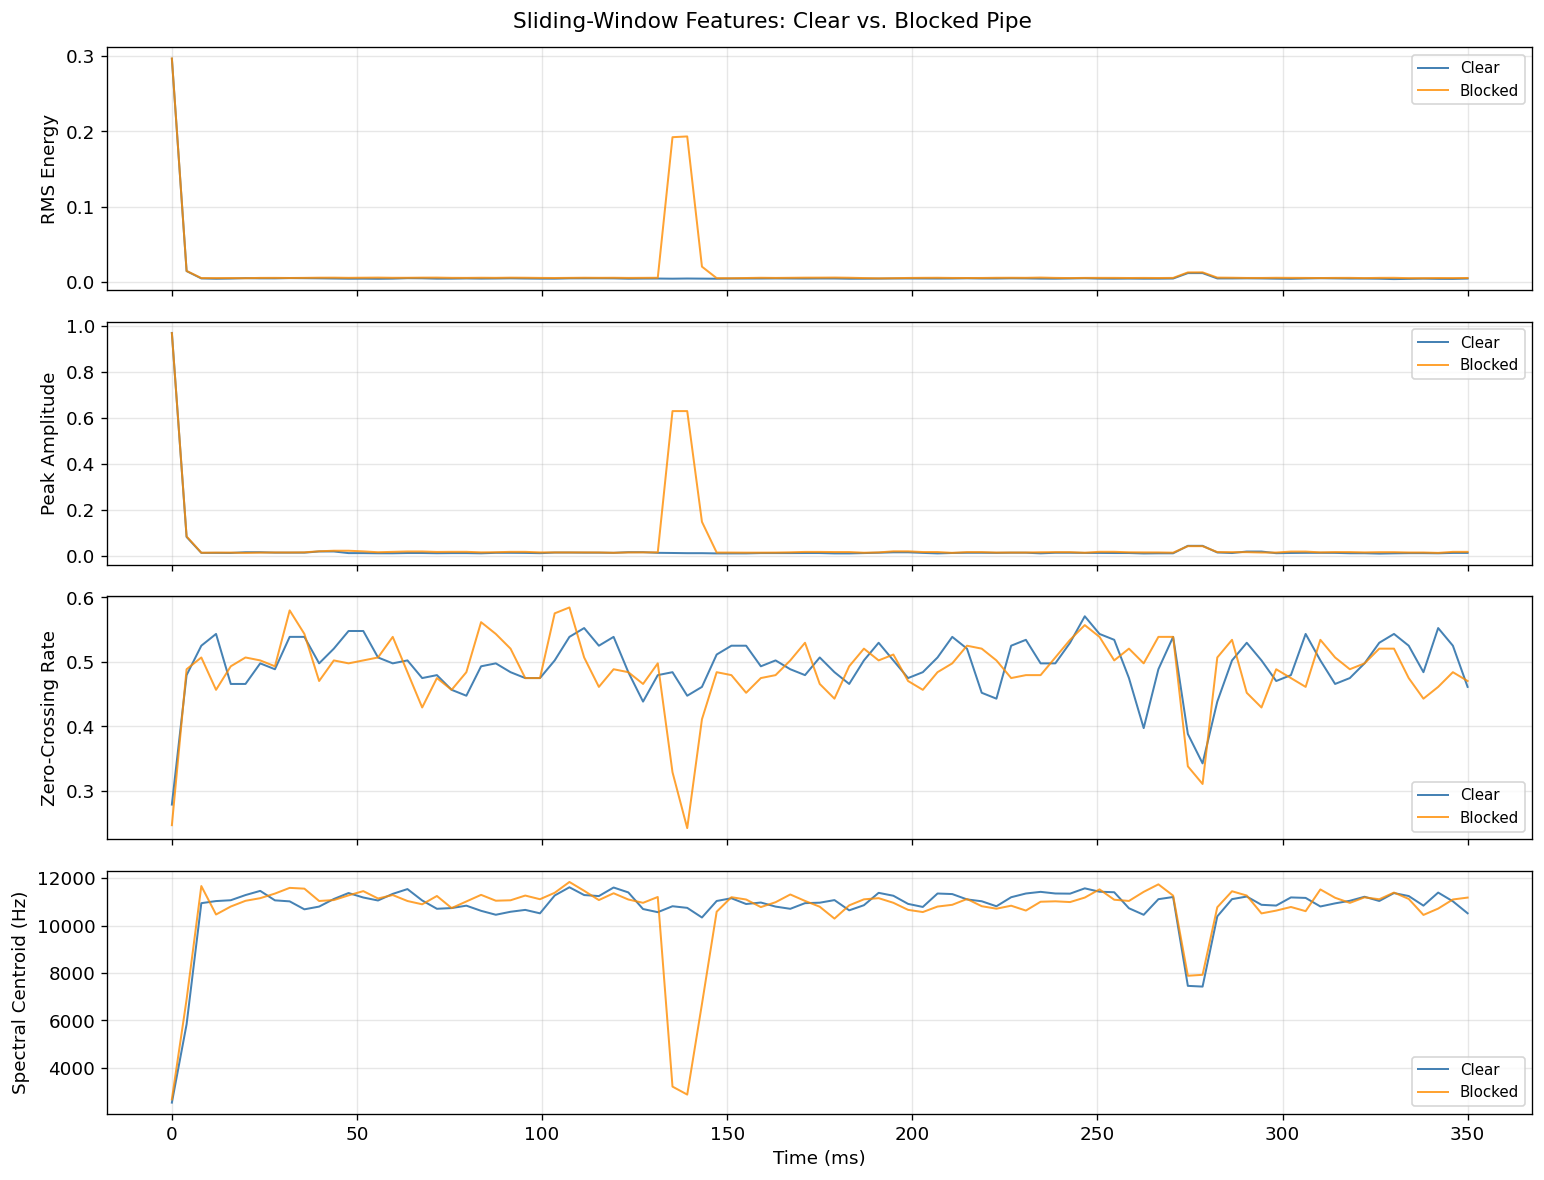

Feature shape per signal: (89, 4)  (windows × features)


In [5]:
feats_clear   = extract_envelope_features(sig_clear, fs=FS)
feats_blocked = extract_envelope_features(sig_blk,   fs=FS)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
feat_names = ['RMS Energy', 'Peak Amplitude', 'Zero-Crossing Rate', 'Spectral Centroid (Hz)']
colors = ['steelblue', 'darkorange']

n_windows = feats_clear.shape[0]
t_windows = np.linspace(0, 350, n_windows)  # ms

for i, (ax, name) in enumerate(zip(axes, feat_names)):
    ax.plot(t_windows, feats_clear[:, i],   label='Clear',   color=colors[0], linewidth=1.2)
    ax.plot(t_windows, feats_blocked[:, i], label='Blocked', color=colors[1], linewidth=1.2, alpha=0.8)
    ax.set(ylabel=name)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time (ms)')
fig.suptitle('Sliding-Window Features: Clear vs. Blocked Pipe', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/plots/02_sliding_window_features.png', bbox_inches='tight')
plt.show()
print(f'Feature shape per signal: {feats_clear.shape}  (windows × features)')

## 2.5 Generate Spectrogram Dataset for ML Training

Convert all 2,000 signals to normalised spectrogram tensors and save for use
in the detection notebook.

In [6]:
print('Computing spectrograms for full dataset (this may take ~1 min)...')

specs = spectrogram_batch(
    signals, fs=FS,
    nperseg=512, noverlap=384,
    freq_max=8_000,
    target_time_bins=64,
)

np.save('../outputs/features/spectrograms.npy', specs)
print(f'Spectrograms saved: shape={specs.shape}  dtype={specs.dtype}')
print(f'Memory: {specs.nbytes / 1e6:.1f} MB')

# Also save normalised raw signals for the localiser
sigs_norm = normalise_signals(signals)
np.save('../outputs/features/signals_norm.npy', sigs_norm)
print(f'Normalised signals saved: shape={sigs_norm.shape}')

Computing spectrograms for full dataset (this may take ~1 min)...


Spectrograms saved: shape=(2000, 1, 93, 64)  dtype=float32
Memory: 47.6 MB


Normalised signals saved: shape=(2000, 15434)


## 2.6 Spectrogram Gallery
Quick sanity-check: visualise 8 spectrograms (4 clear, 4 blocked).

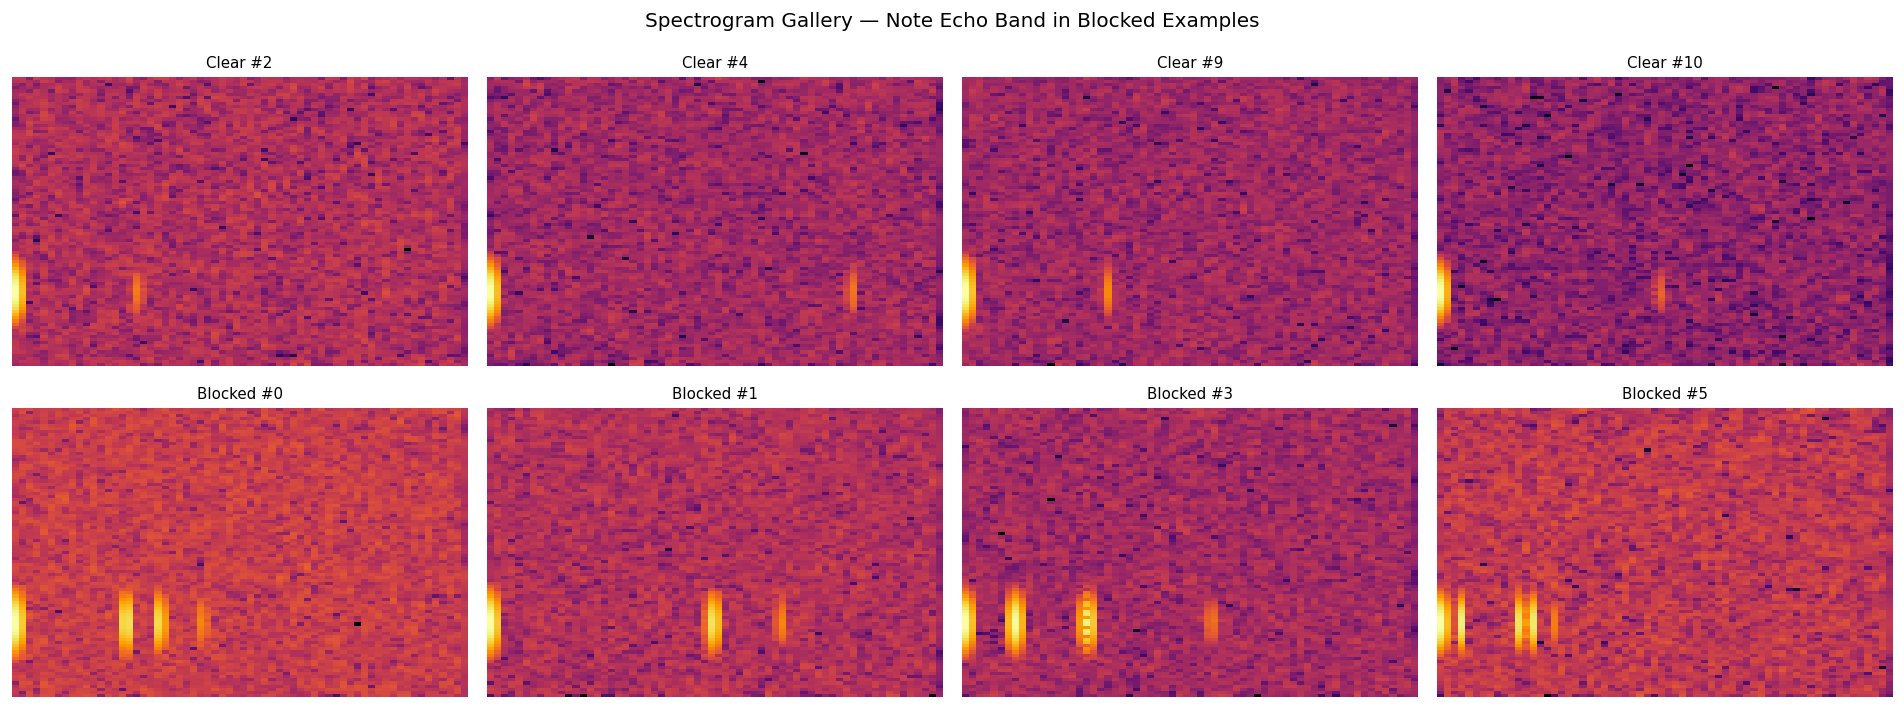

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

clear_idx   = np.where(labels == 0)[0][:4]
blocked_idx = np.where(labels == 1)[0][:4]

for col, idx in enumerate(clear_idx):
    axes[0, col].imshow(specs[idx, 0], aspect='auto', origin='lower',
                        cmap='inferno', vmin=0, vmax=1)
    axes[0, col].set_title(f'Clear #{idx}', fontsize=9)
    axes[0, col].axis('off')

for col, idx in enumerate(blocked_idx):
    axes[1, col].imshow(specs[idx, 0], aspect='auto', origin='lower',
                        cmap='inferno', vmin=0, vmax=1)
    axes[1, col].set_title(f'Blocked #{idx}', fontsize=9)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Clear', fontsize=10)
axes[1, 0].set_ylabel('Blocked', fontsize=10)
fig.suptitle('Spectrogram Gallery — Note Echo Band in Blocked Examples', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/plots/02_spectrogram_gallery.png', bbox_inches='tight')
plt.show()